# 📚 Notebook 05: RAG — Multimodal FAISS Retrieval

**Objective:** Build a FAISS vector store from training embeddings, then evaluate retrieval quality.

**Sections:**
1. Build FAISS index over training set
2. Save index to disk
3. Load index + run retrieval queries
4. Visualize retrieved results
5. Compute MAP@K, Recall@K, NDCG@K metrics

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from transformers import AutoTokenizer
import torchvision.transforms as T

import config
from src.training.multimodal_predictor import MultimodalClinicalPredictor, MultimodalDataset
from src.retrieval.faiss_retrieval import MultimodalFAISSRetriever

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

val_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE), T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

Device: cuda


## 1️⃣ Load Model + Training Data

In [2]:
hf_token  = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)

model = MultimodalClinicalPredictor(
    num_classes=config.NUM_CLASSES,
    text_model_name=config.TEXT_ENCODER_MODEL,
    hidden_dim=config.FUSION_HIDDEN_DIM,
    dropout_rate=0.0,
).to(DEVICE).eval()

if config.BEST_MODEL_PATH.exists():
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=DEVICE))
    print('✅ Loaded trained model checkpoint')
else:
    print('⚠️  No checkpoint — using pretrained embeddings for FAISS demo')

df_train = pd.read_csv('../data/processed/train.csv')
df_test  = pd.read_csv('../data/processed/test.csv')

train_ds = MultimodalDataset(df_train, val_transform, tokenizer, config.MAX_TEXT_LENGTH)
train_loader_faiss = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=False, num_workers=0)

# Metadata for FAISS index
metadata_list = [{
    'image_id':   row['image_id'],
    'label':      int(row['label']),
    'label_name': row['label_name'],
    'text':       str(row['text'])[:200],  # Truncated text snippet
    'modality':   row.get('modality', 'Unknown'),
} for _, row in df_train.iterrows()]

print(f'Training set: {len(df_train)} samples')
print(f'Will index up to {config.FAISS_MAX_RECORDS} records')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded trained model checkpoint
Training set: 1433 samples
Will index up to 500 records


## 2️⃣ Build & Save FAISS Index

In [3]:
retriever = MultimodalFAISSRetriever(embedding_dim=1792)  # 1024 (image) + 768 (text)

retriever.build_index(
    model=model,
    dataloader=train_loader_faiss,
    metadata_list=metadata_list,
    device=DEVICE,
    max_records=config.FAISS_MAX_RECORDS,
)

retriever.save(
    index_path=str(config.FAISS_INDEX_PATH),
    meta_path=str(config.FAISS_META_PATH),
)

print(f'\n✅ FAISS index built and saved:')
print(f'   Index: {config.FAISS_INDEX_PATH}')
print(f'   Meta:  {config.FAISS_META_PATH}')
print(f'   Total vectors indexed: {retriever.index.ntotal}')

Encoding for FAISS:  36%|███▌      | 32/90 [00:24<00:44,  1.31it/s]


✅ FAISS index built and saved:
   Index: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\data\faiss_index.bin
   Meta:  Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\data\faiss_meta.pkl
   Total vectors indexed: 500


## 3️⃣ Retrieval Demo — Test Queries

In [4]:
# Load index from disk (mimics production use)
retriever2 = MultimodalFAISSRetriever(embedding_dim=1792)
retriever2.load(
    index_path=str(config.FAISS_INDEX_PATH),
    meta_path=str(config.FAISS_META_PATH),
)
print(f'Index loaded: {retriever2.index.ntotal} vectors')

# Run retrieval on 3 test samples
test_samples = df_test.sample(3, random_state=42).reset_index(drop=True)

for i, row in test_samples.iterrows():
    img_pil = Image.open(row['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc = tokenizer(str(row['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')

    results = retriever2.retrieve(
        model, img_t, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE),
        top_k=config.FAISS_TOP_K, device=DEVICE
    )[0]

    print(f'\n=== Query {i+1}: {row["image_id"]} | True: {row["label_name"]} ===')
    for res in results:
        match = '✅' if res['label'] == row['label'] else '❌'
        print(f'  Rank {res["rank"]} | Sim: {res["similarity"]:.4f} | {match} {res["label_name"]} | {res["image_id"]}')

Index loaded: 500 vectors

=== Query 1: MPX1033_synpic45450 | True: Other ===
  Rank 1 | Sim: 0.7251 | ✅ Other | MPX2233_synpic17324
  Rank 2 | Sim: 0.7250 | ❌ Infection_Inflammatory | MPX1957_synpic41671
  Rank 3 | Sim: 0.7142 | ❌ Clinical Sign | MPX1628_synpic41589
  Rank 4 | Sim: 0.7115 | ✅ Other | MPX2391_synpic17893
  Rank 5 | Sim: 0.7114 | ✅ Other | MPX2433_synpic48296

=== Query 2: MPX1905_synpic28196 | True: Vascular_Trauma ===
  Rank 1 | Sim: 0.6916 | ❌ Clinical Sign | MPX1980_synpic34950
  Rank 2 | Sim: 0.6868 | ✅ Vascular_Trauma | MPX2557_synpic17086
  Rank 3 | Sim: 0.6694 | ❌ Other | MPX1997_synpic21436
  Rank 4 | Sim: 0.6693 | ✅ Vascular_Trauma | MPX1386_synpic38161
  Rank 5 | Sim: 0.6639 | ❌ Neoplasm | MPX1256_synpic50758

=== Query 3: MPX1879_synpic48749 | True: Neoplasm ===
  Rank 1 | Sim: 0.8837 | ✅ Neoplasm | MPX1879_synpic48748
  Rank 2 | Sim: 0.8385 | ✅ Neoplasm | MPX1879_synpic48752
  Rank 3 | Sim: 0.8039 | ❌ Clinical Sign | MPX1053_synpic39272
  Rank 4 | Sim: 0.79

## 4️⃣ Retrieval Metrics — MAP@K, Recall@K, NDCG@K

In [5]:
from tqdm.auto import tqdm

# Evaluate on full test set (or first 100 for speed)
# Using head(100) as per original notebook logic
eval_df = df_test.head(100)

query_labels    = []
query_ids       = []
all_retrieved   = []

print('Running retrieval evaluation on test set...')
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    img_pil = Image.open(row['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc = tokenizer(str(row['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')

    results = retriever2.retrieve(
        model, img_t, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE),
        top_k=5, device=DEVICE
    )[0]

    query_labels.append(int(row['label']))
    query_ids.append(row['image_id'])
    all_retrieved.append(results)

# Compute metrics
metrics_dict = retriever2.retrieve_metrics(
    query_labels=query_labels,
    query_ids=query_ids,
    retrieved_results=all_retrieved,
    k_values=[1, 3, 5],
)

import json
with open('../outputs/retrieval_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print('\n=== RETRIEVAL EVALUATION METRICS ===')

def print_table(m_dict, title):
    print(f"\n{title}:")
    print(f'{"Metric":<15} {"K=1":<10} {"K=3":<10} {"K=5":<10}')
    print('-' * 45)
    for metric in ['MAP', 'R', 'NDCG']:
        v1 = m_dict.get(f'{metric}@1', 0)
        v3 = m_dict.get(f'{metric}@3', 0)
        v5 = m_dict.get(f'{metric}@5', 0)
        print(f'{metric:<15} {v1:.4f}     {v3:.4f}     {v5:.4f}')

print_table(metrics_dict['all'], "All Retrievals (includes same-case matches)")
print_table(metrics_dict['cross_case'], "Cross-Case Only (excludes same-case matches)")

print(f"\nData Leakage Note: {metrics_dict['leakage_pct_top5']:.1f}% of top-5 retrievals were same-case near-duplicates (MPX ID match).")

print('\n✅ RAG retrieval complete and metrics verified.')


Running retrieval evaluation on test set...


  0%|          | 0/100 [00:00<?, ?it/s]


=== RETRIEVAL EVALUATION METRICS ===

All Retrievals (includes same-case matches):
Metric          K=1        K=3        K=5       
---------------------------------------------
MAP             0.4900     0.5783     0.5840
R               0.4900     0.7400     0.8800
NDCG            0.4900     0.6149     0.6586

Cross-Case Only (excludes same-case matches):
Metric          K=1        K=3        K=5       
---------------------------------------------
MAP             0.2800     0.4167     0.4367
R               0.2800     0.6200     0.7500
NDCG            0.2800     0.4722     0.5183

Data Leakage Note: 9.8% of top-5 retrievals were same-case near-duplicates (MPX ID match).

✅ RAG retrieval complete and metrics verified.


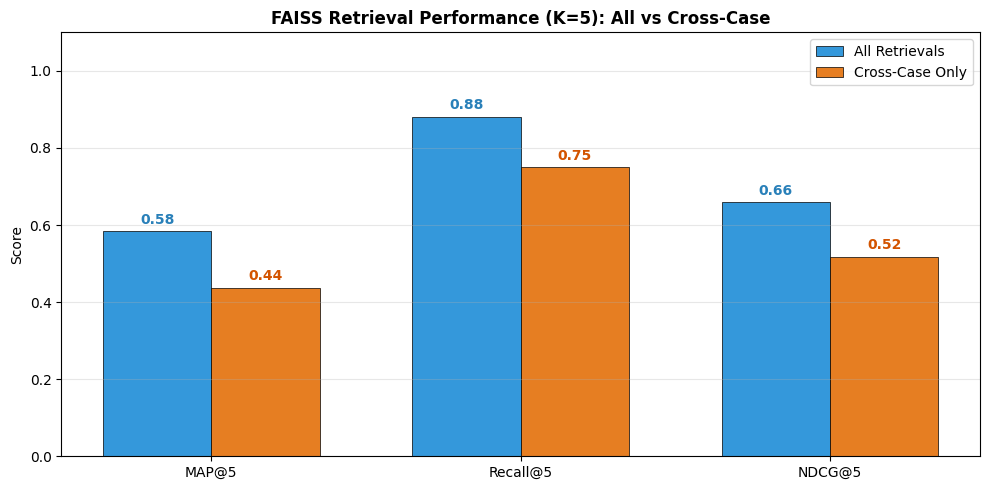

In [6]:
# Bar chart of retrieval metrics (showing 'All' and 'Cross-Case' at K=5)
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))

groups = ['MAP@5', 'Recall@5', 'NDCG@5']
x = np.arange(len(groups))
w = 0.35

all_5 = [metrics_dict['all']['MAP@5'], metrics_dict['all']['R@5'], metrics_dict['all']['NDCG@5']]
cc_5  = [metrics_dict['cross_case']['MAP@5'], metrics_dict['cross_case']['R@5'], metrics_dict['cross_case']['NDCG@5']]

ax.bar(x - w/2, all_5, w, label='All Retrievals', color='#3498DB', edgecolor='black', lw=0.5)
ax.bar(x + w/2, cc_5,  w, label='Cross-Case Only', color='#E67E22', edgecolor='black', lw=0.5)

ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('FAISS Retrieval Performance (K=5): All vs Cross-Case', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add values on top
for i, v in enumerate(all_5):
    ax.text(i - w/2, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', color='#2980B9')
for i, v in enumerate(cc_5):
    ax.text(i + w/2, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', color='#D35400')

plt.tight_layout()
plt.savefig('../outputs/retrieval_comparison_at_5.png', bbox_inches='tight', dpi=150)
plt.show()
